# Model Final — Random Forest

Melatih ulang model final, evaluasi mendalam, dan demo prediksi.

In [2]:
import sys
sys.path.append("../src")

from preprocessing import load_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

X_train, y_train, X_test, y_test, feature_cols = load_dataset(
    train_path="../data/Training.csv", test_path="../data/Testing.csv"
)

encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train_enc)

pred = model.predict(X_test)
print(classification_report(y_test_enc, pred, target_names=encoder.classes_, zero_division=0))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

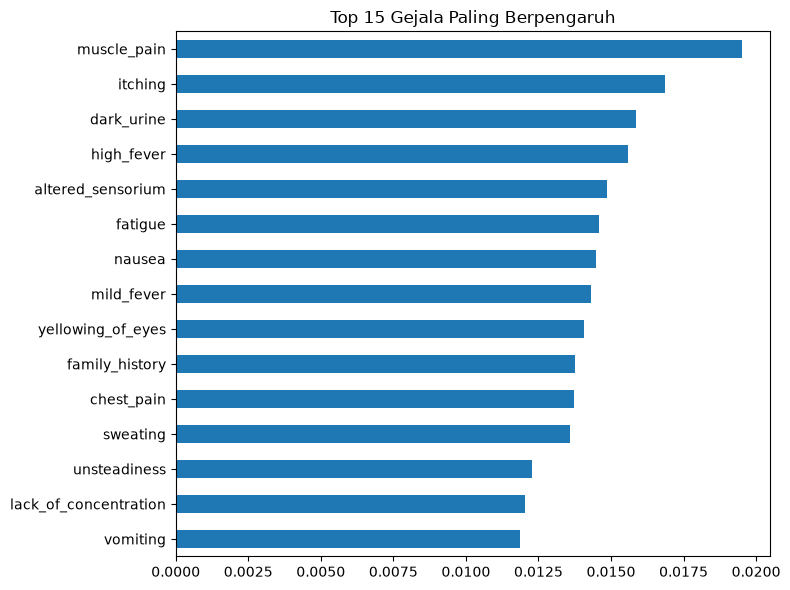

In [3]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Gejala Paling Berpengaruh")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Kasus Salah Prediksi

Satu-satunya kesalahan: **Fungal infection** ditebak sebagai **Impetigo**, dengan
gejala `itching, skin_rash, red_spots_over_body, family_history, skin_peeling,
red_sore_around_nose`. Kombinasi ini secara gejala kulit memang tumpang tindih
antara dua penyakit tersebut — contoh nyata batas kemampuan model saat gejalanya
ambigu.

In [4]:
sys.path.append("..")
from src.pewdict import predict_from_symptoms

# Demo: simulasi input checklist dari user
hasil = predict_from_symptoms(["itching", "skin_rash", "high_fever"])
hasil

{'prediksi_utama': 'Fungal infection',
 'kandidat': [{'penyakit': 'Fungal infection', 'probabilitas': 0.325},
  {'penyakit': 'Impetigo', 'probabilitas': 0.26},
  {'penyakit': 'Drug Reaction', 'probabilitas': 0.145}],
 'gejala_tidak_dikenali': []}

## Kesimpulan Proyek

- Model final: **Random Forest** (200 trees), akurasi 97.62% di data testing.
- Dipilih karena interpretabilitasnya (`feature_importances_`), bukan semata
  akurasi tertinggi.
- Output prediksi berupa **top-3 kandidat** dengan probabilitas, bukan 1 jawaban
  tunggal — supaya kasus ambigu tetap terlihat transparan ke user.

**Keterbatasan:** dataset ini sintetis dan deterministik (304 kombinasi gejala
unik untuk 41 penyakit). Performa setinggi ini **tidak mencerminkan performa
di dunia nyata**, di mana gejala pasien jauh lebih bervariasi dan tumpang
tindih. Proyek ini adalah demonstrasi *pipeline* machine learning end-to-end,
**bukan alat diagnosis medis yang siap pakai**.